<a href="https://colab.research.google.com/github/PavlovIO/spbu-python-course/blob/assignment7/project/hw7/Task7Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

--2025-11-21 19:40:13--  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘iris.data.3’

iris.data.3             [ <=>                ]   4.44K  --.-KB/s    in 0s      

2025-11-21 19:40:13 (55.8 MB/s) - ‘iris.data.3’ saved [4551]



In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

### Загрузка датасета

In [164]:
data, names = np.genfromtxt('iris.data', delimiter=',', dtype=None, usecols=(0,1,2,3)), np.genfromtxt('iris.data', delimiter=',', dtype=None, usecols=4)

### Измерение занимаемой памяти

In [165]:
print(f'Iris traits dataset takes {data.nbytes/1000}kb')
print(f'Iris names dataset takes {names.nbytes/1000}kb')

Iris traits dataset takes 4.8kb
Iris names dataset takes 9.0kb


### Нормализация данных

In [166]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

### Разделение на категориальный признак

<Axes: xlabel='Type', ylabel='count'>

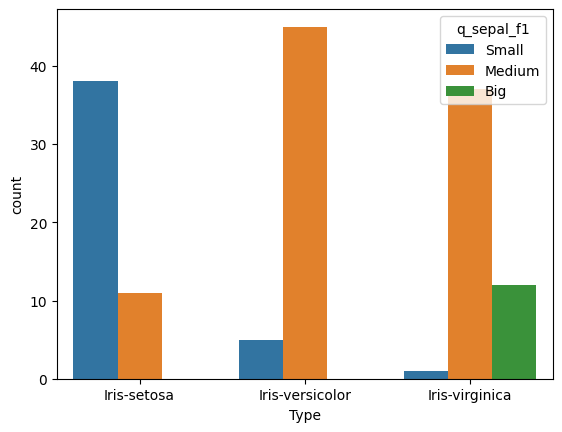

In [236]:
sepal_length = scaled_data[:,0]
custom = [0, 0.25, 0.75, 1.0]
sepal_cut = pd.cut( sepal_length, bins=custom, labels=['Small','Medium','Big'])
df = pd.DataFrame(scaled_data, columns=['f1','f2','f3','f4'])
df['Type'] = names
df['q_sepal_f1'] = sepal_cut
sns.countplot(data=df, x='Type', hue='q_sepal_f1')

### Для обучения выбрана модель *RandomForestClassifier*

In [244]:
lable = LabelEncoder()
y = lable.fit_transform(names)

x_train, x_test, y_train, y_test = train_test_split(
    scaled_data, y,
    train_size=0.8,
    stratify=y
)

rf = RandomForestClassifier(n_estimators=5)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


#### Вывод:
Модель хорошо обучилась на датасете с точностью 0.966 , неточности связанны с небольшой выборкой для тестирования.

### Проведение экспериментов с различными гиперпараметрами

In [168]:
rf5_5 = RandomForestClassifier(n_estimators=5, max_depth=5)
rf10_5 = RandomForestClassifier(n_estimators=10, max_depth=5)
rf5_3 = RandomForestClassifier(n_estimators=5, max_depth=3)
rf10_3 = RandomForestClassifier(n_estimators=10, max_depth=3)

accuracies5_5=[]
accuracies10_5=[]
accuracies5_3=[]
accuracies10_3=[]
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        scaled_data, y, test_size=0.2, random_state=seed, stratify=y
    )
    rf5_5.fit(X_train,y_train)
    rf10_5.fit(X_train,y_train)
    rf5_3.fit(X_train,y_train)
    rf10_3.fit(X_train,y_train)

    y5_5 = rf5_5.predict(X_test)
    y10_5 = rf10_5.predict(X_test)
    y5_3 = rf5_3.predict(X_test)
    y10_3 = rf10_3.predict(X_test)
    accuracies5_5.append(rf5_5.score(X_test, y_test))
    accuracies10_5.append(rf10_5.score(X_test, y_test))
    accuracies5_3.append(rf5_3.score(X_test, y_test))
    accuracies10_3.append(rf10_3.score(X_test, y_test))
print("Tests with scaled to range from 0 to 1 data")
print(f"Average accuracy 5_5: {np.mean(accuracies5_5):.3f} (+/- {np.std(accuracies5_5):.3f})")
print(f"Average accuracy 10_5: {np.mean(accuracies10_5):.3f} (+/- {np.std(accuracies10_5):.3f})")
print(f"Average accuracy 5_3: {np.mean(accuracies5_3):.3f} (+/- {np.std(accuracies5_3):.3f})")
print(f"Average accuracy 10_3: {np.mean(accuracies10_3):.3f} (+/- {np.std(accuracies10_3):.3f})")
print()
accuracies5_5=[]
accuracies10_5=[]
accuracies5_3=[]
accuracies10_3=[]
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        data, y, test_size=0.2, random_state=seed, stratify=y
    )
    rf5_5.fit(X_train,y_train)
    rf10_5.fit(X_train,y_train)
    rf5_3.fit(X_train,y_train)
    rf10_3.fit(X_train,y_train)

    y5_5 = rf5_5.predict(X_test)
    y10_5 = rf10_5.predict(X_test)
    y5_3 = rf5_3.predict(X_test)
    y10_3 = rf10_3.predict(X_test)
    accuracies5_5.append(rf5_5.score(X_test, y_test))
    accuracies10_5.append(rf10_5.score(X_test, y_test))
    accuracies5_3.append(rf5_3.score(X_test, y_test))
    accuracies10_3.append(rf10_3.score(X_test, y_test))
print("Tests with not scaled data")
print(f"Average accuracy 5_5: {np.mean(accuracies5_5):.3f} (+/- {np.std(accuracies5_5):.3f})")
print(f"Average accuracy 10_5: {np.mean(accuracies10_5):.3f} (+/- {np.std(accuracies10_5):.3f})")
print(f"Average accuracy 5_3: {np.mean(accuracies5_3):.3f} (+/- {np.std(accuracies5_3):.3f})")
print(f"Average accuracy 10_3: {np.mean(accuracies10_3):.3f} (+/- {np.std(accuracies10_3):.3f})")

Tests with scaled to range from 0 to 1 data
Average accuracy 5_5: 0.960 (+/- 0.029)
Average accuracy 10_5: 0.953 (+/- 0.027)
Average accuracy 5_3: 0.953 (+/- 0.031)
Average accuracy 10_3: 0.953 (+/- 0.043)

Tests with not scaled data
Average accuracy 5_5: 0.957 (+/- 0.037)
Average accuracy 10_5: 0.960 (+/- 0.029)
Average accuracy 5_3: 0.937 (+/- 0.041)
Average accuracy 10_3: 0.957 (+/- 0.026)


### Вывод
Основываясь на проведенных экспериментах с моделью *RandomForestClassifier* и изменением 2 гиперпараметров *(n_estimators=5,10, max_depth=3,5)* с нормализованными и не нормализованными данными были получены следующие результаты:
 - С нормализацией лучшая точность 0,963 при параметрах n_estimators=10, max_depth=5
 - Без нормализации лучшая точность 0,967 при параметрах n_estimators=5, max_depth=5
 - Разница между различными комбинициями параметров и данных находятся в пределах стандартного отклонения

 Это означает, что:
 - на данном не большом датасете *Iris* модель устойчива к изменениям гиперпараметров и нормализации данных
 - незначительные изменения в точности связанны с небольшой тестовой выборкой

### Визуализация данных с уменьшением размерности

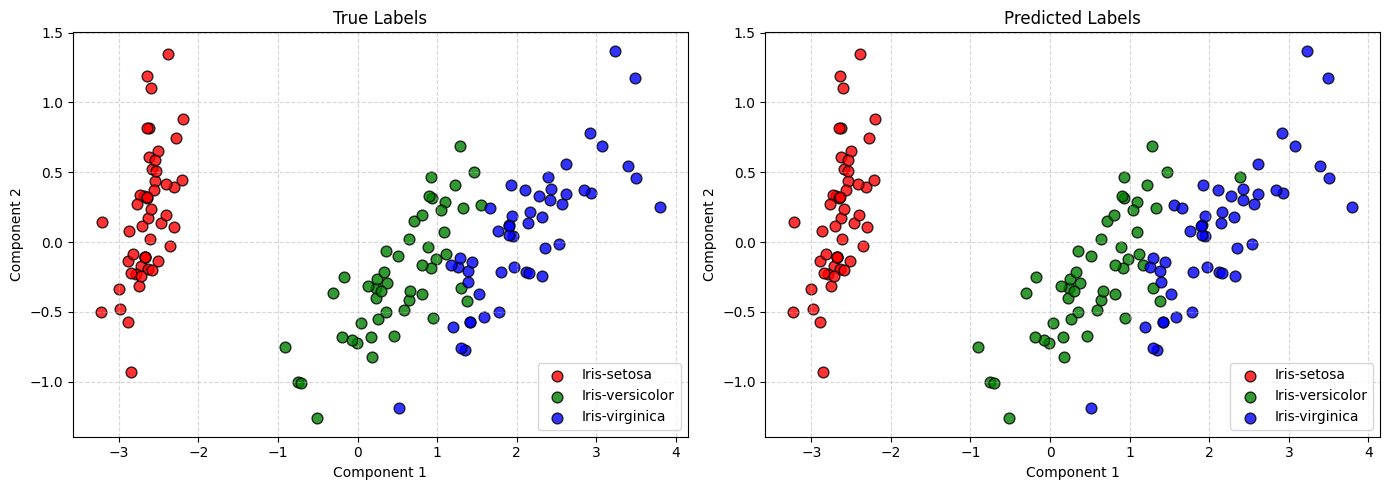

In [221]:
X_train, X_test, y_train, y_test = train_test_split(
    data, y, test_size=0.2, random_state=seed, stratify=y
)
rf5_5.fit(X_train,y_train)
y_pred = rf5_5.predict(data)
types = ['Iris-setosa','Iris-versicolor','Iris-virginica']

pca = PCA(n_components=2)
x_pca = pca.fit_transform(data)

colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y, title in zip(axes, [y, y_pred], ['True Labels', 'Predicted Labels']):
    for i, (name, color) in enumerate(zip(types, colors)):
        mask = (y == i)
        ax.scatter(x_pca[mask, 0], x_pca[mask, 1],
                   c=color, label=name, alpha=0.8, edgecolors='k', s=60)
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



